In [6]:
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
world_castles = pd.read_csv('https://raw.githubusercontent.com/rfordatascience/tidytuesday/main/data/2026/2026-09-01/world_castles.csv')

In [4]:
world_castles.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5793 entries, 0 to 5792
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   qid          5793 non-null   object 
 1   name         5793 non-null   object 
 2   category     5793 non-null   object 
 3   country      5793 non-null   object 
 4   iso          5788 non-null   object 
 5   lat          5793 non-null   float64
 6   lon          5793 non-null   float64
 7   year         3610 non-null   float64
 8   year_approx  5793 non-null   int64  
 9   century      3610 non-null   object 
 10  wikipedia    5793 non-null   object 
 11  image        5793 non-null   object 
 12  sitelinks    5793 non-null   int64  
 13  pageviews    5792 non-null   float64
 14  fame_rank    5793 non-null   int64  
dtypes: float64(4), int64(3), object(8)
memory usage: 679.0+ KB


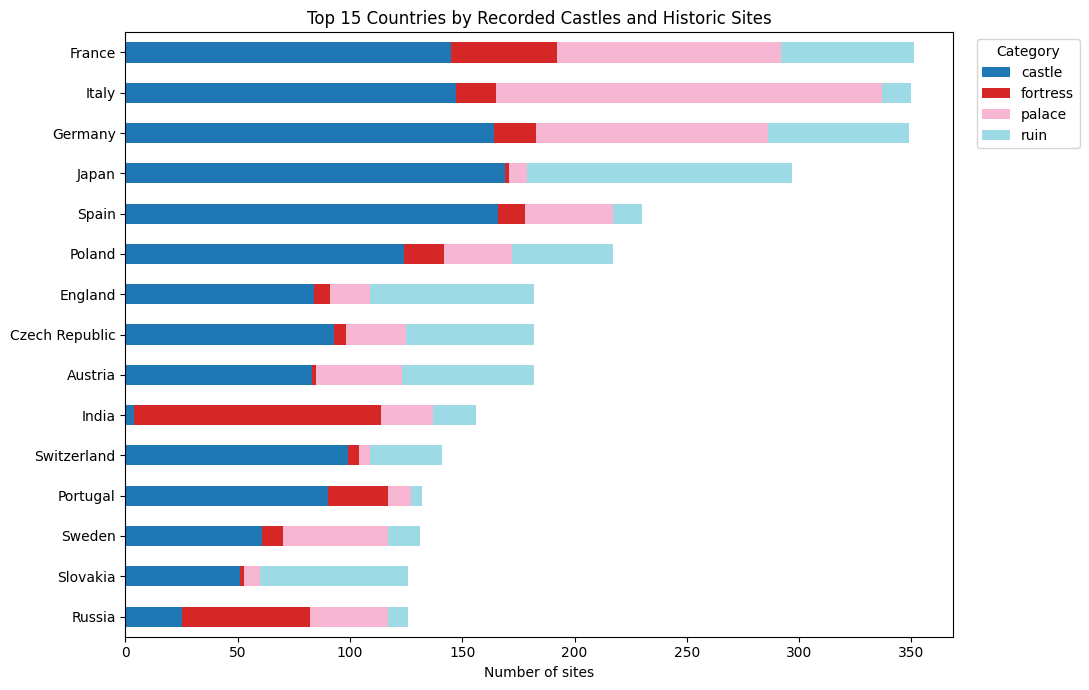

In [5]:
# Top 15 countries by number of recorded castles, split by category
category_counts = (
    world_castles.groupby(["country", "category"])
    .size()
    .unstack(fill_value=0)
)

top_countries = category_counts.sum(axis=1).nlargest(15).sort_values()

ax = top_countries.to_frame("total").join(category_counts).drop(columns="total").plot(
    kind="barh",
    stacked=True,
    figsize=(11, 7),
    colormap="tab20"
)

ax.set_title("Top 15 Countries by Recorded Castles and Historic Sites")
ax.set_xlabel("Number of sites")
ax.set_ylabel("")
ax.legend(title="Category", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

# Exploring World Castles and Historic Sites

This dataset contains **5,793 recorded sites across 138 countries**. Each site is classified as a castle, fortress, palace, or ruin, with additional information such as geographic coordinates, construction date, Wikipedia links, page views, and fame rank.

## Chart Overview

The chart displays the **15 countries with the highest total number of recorded sites**. Each horizontal bar is divided into categories, showing how castles, fortresses, palaces, and ruins contribute to each country’s total.

France, Italy, Germany, and Japan appear among the countries with the largest numbers of recorded sites. The stacked format makes it possible to compare both the overall total and the category composition of each country.

These values represent sites recorded in this dataset, not necessarily the complete number of historic sites in each country.

## Code Logic

The analysis first groups the data by country and category:

```python
world_castles.groupby(["country", "category"]).size()
```

The result is reshaped so that categories become columns, with missing combinations filled with zero:

```python
.unstack(fill_value=0)
```

The category totals are then summed by country. The 15 largest totals are selected and sorted for clearer display. Finally, the data is plotted as a horizontal stacked bar chart, with one color for each category.

## Possible Additional Charts

Several other charts could provide useful perspectives:

- **Map of sites:** Plot latitude and longitude to show geographic distribution.
- **Category comparison:** Use a grouped bar chart to compare site types by country.
- **Historical timeline:** Show the number of sites by century or construction year.
- **Popularity analysis:** Compare Wikipedia page views with fame rank.
- **Top individual sites:** Display the most famous sites using fame rank or page views.
- **Country-level totals:** Create a choropleth map showing recorded sites by country.
- **Missing-date analysis:** Compare sites with known and unknown construction dates.
- **Category proportions:** Use a 100% stacked bar chart to compare the composition of each country’s sites.

Together, these visualizations could examine not only where sites are located, but also their historical periods, categories, and levels of public interest.